In [1]:
import os, math, copy, random, time
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# =========================================================
CSV_PATH = "AnonDB.csv"
IMAGE_SIZE = 380
BATCH_SIZE = 8
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available(): print("GPU name:", torch.cuda.get_device_name(0))

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(RANDOM_SEED)

# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str): return None
    path_str = str(path_str).strip()
    if path_str == "": return None
    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)
    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"): path_str = root + "_wrp" + ext
    if os.path.isabs(path_str): return os.path.normpath(path_str)
    if path_str.startswith("." + os.sep): path_str = path_str[2:]
    return os.path.normpath(os.path.join(base_dir, path_str))

def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)
    for col in ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]:
        if col not in df.columns: raise ValueError(f"Missing: {col}")
    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")
    df = df[df["Nameplate_Pmp_(W)"].notna() & (df["Nameplate_Pmp_(W)"] > 0) & df["Pmp_(W)"].notna()]
    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]
    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df = df[df["high_path"].notna()]
    df["high_exists"] = df["high_path"].apply(os.path.exists)
    before = len(df); df = df[df["high_exists"]].copy()
    print(f"Rows before file filter: {before} | After: {len(df)} | Removed: {before - len(df)}")
    keep = [c for c in ["ID","ModuleID","Module","Serial","PanelID"] if c in df.columns] + ["high_path","pf_ratio"]
    return df[keep].reset_index(drop=True)

# =========================================================
class SingleELDataset(Dataset):
    def __init__(self, dataframe, image_size=380, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size; self.augment = augment; self.cache = None
        if preload: self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        mb = n * self.image_size * self.image_size / (1024**2)
        print(f"\n  Preloading {n} high-bias images into RAM (~{mb:.0f} MB)...")
        t0 = time.time()
        self.cache_high = np.empty((n, self.image_size, self.image_size), dtype=np.uint8)
        failed = 0
        for i in range(n):
            try:
                self.cache_high[i] = cv2.resize(cv2.imread(self.df.iloc[i]["high_path"], cv2.IMREAD_GRAYSCALE), (self.image_size,self.image_size))
            except: self.cache_high[i]=0; failed+=1
        print(f"  Done in {time.time()-t0:.1f}s | RAM: {self.cache_high.nbytes/(1024**2):.1f} MB | Failed: {failed}")
        self.cache = True

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.cache: img = self.cache_high[idx].copy()
        else: img = cv2.resize(cv2.imread(row["high_path"], cv2.IMREAD_GRAYSCALE), (self.image_size,self.image_size))
        if self.augment:
            if random.random()<0.5: img=cv2.flip(img,1)
            if random.random()<0.5: img=cv2.flip(img,0)
        x = np.expand_dims(img.astype(np.float32)/255.0, axis=0)  # [1, H, W]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(row["pf_ratio"], dtype=torch.float32)

class BoundedOutput(nn.Module):
    def __init__(self, f, lo=0.80, hi=1.20):
        super().__init__(); self.linear=nn.Linear(f,1); self.lo=lo; self.hi=hi
    def forward(self, x):
        return torch.sigmoid(self.linear(x))*(self.hi-self.lo)+self.lo

def build_model(pretrained=True):
    weights = models.EfficientNet_B4_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b4(weights=weights)
    old = model.features[0][0]
    new = nn.Conv2d(1, old.out_channels, old.kernel_size, old.stride, old.padding, bias=False)
    with torch.no_grad():
        if pretrained:
            new.weight[:,0] = old.weight.mean(dim=1)  # average 3 RGB channels into 1
        else: nn.init.kaiming_normal_(new.weight, mode="fan_out", nonlinearity="relu")
    model.features[0][0] = new
    model.classifier[1] = BoundedOutput(model.classifier[1].in_features)
    return model

# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train(); loss_sum=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device).unsqueeze(1)
        optimizer.zero_grad(); out=model(x); loss=criterion(out,y); loss.backward(); optimizer.step()
        loss_sum+=loss.item()*x.size(0)
    return loss_sum/len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval(); loss_sum=0.0; preds=[]; trues=[]
    with torch.no_grad():
        for x,y in loader:
            x=x.to(device); y=y.to(device).unsqueeze(1)
            out=model(x); loss=criterion(out,y); loss_sum+=loss.item()*x.size(0)
            preds.extend(out.squeeze(1).cpu().numpy()); trues.extend(y.squeeze(1).cpu().numpy())
    preds=np.array(preds); trues=np.array(trues)
    return loss_sum/len(loader.dataset), mean_absolute_error(trues,preds), math.sqrt(mean_squared_error(trues,preds)), r2_score(trues,preds), preds, trues

def plot_scatter(ax, t, p, title):
    ax.scatter(t,p,alpha=0.7); mn=min(t.min(),p.min()); mx=max(t.max(),p.max())
    ax.plot([mn,mx],[mn,mx],'--'); ax.set_xlabel("Actual PF Ratio"); ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title); ax.grid(True)

# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=RANDOM_SEED)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    train_ds = SingleELDataset(train_df, IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM)
    val_ds   = SingleELDataset(val_df,   IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM)
    test_ds  = SingleELDataset(test_df,  IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM)
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = build_model(pretrained=True).to(DEVICE)
    bb = list(model.features.parameters()); hd = list(model.classifier.parameters())
    print(f"\nBackbone: {sum(p.numel() for p in bb):,} | Head: {sum(p.numel() for p in hd):,}")

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW([{"params":bb,"lr":BACKBONE_LR},{"params":hd,"lr":LEARNING_RATE}], weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_wts=copy.deepcopy(model.state_dict()); best_rmse=float("inf")
    tr_l=[]; vl_l=[]; te_l=[]; h_lr=[]; b_lr=[]

    print(f"\n{'='*70}\nEfficientNet-B4 UNFROZEN | High-bias EL (1ch) | {IMAGE_SIZE}x{IMAGE_SIZE}\n{'='*70}\n")
    t0=time.time()
    for ep in range(NUM_EPOCHS):
        et=time.time()
        b_lr.append(optimizer.param_groups[0]["lr"]); h_lr.append(optimizer.param_groups[1]["lr"])
        train_one_epoch(model, train_ld, criterion, optimizer, DEVICE)
        tl,tm,tr,t2,_,_ = evaluate(model, train_ld, criterion, DEVICE)
        vl,vm,vr,v2,_,_ = evaluate(model, val_ld, criterion, DEVICE)
        xl,xm,xr,x2,_,_ = evaluate(model, test_ld, criterion, DEVICE)
        scheduler.step(vl); tr_l.append(tl); vl_l.append(vl); te_l.append(xl)
        print(f"Ep [{ep+1:02d}/{NUM_EPOCHS}] {time.time()-et:.1f}s | BB_LR:{b_lr[-1]:.2e} Head:{h_lr[-1]:.2e} | TrL:{tl:.6f} VL:{vl:.6f} TL:{xl:.6f} | VMAE:{vm:.6f} VRMSE:{vr:.6f} VR2:{v2:.4f}")
        if vr<best_rmse: best_rmse=vr; best_wts=copy.deepcopy(model.state_dict())
    print(f"\nDone in {time.time()-t0:.1f}s")

    model.load_state_dict(best_wts)
    vl,vm,vr,v2,vp,vt = evaluate(model, val_ld, criterion, DEVICE)
    xl,xm,xr,x2,xp,xt = evaluate(model, test_ld, criterion, DEVICE)
    print(f"\nVal  MAE:{vm:.6f} RMSE:{vr:.6f} R2:{v2:.6f}")
    print(f"Test MAE:{xm:.6f} RMSE:{xr:.6f} R2:{x2:.6f}")

    fig,axes=plt.subplots(2,2,figsize=(14,10))
    plot_scatter(axes[0,0],vt,vp,"Validation: Predicted vs Actual")
    plot_scatter(axes[0,1],xt,xp,"Test: Predicted vs Actual")
    axes[1,0].plot(range(1,NUM_EPOCHS+1),tr_l,'o-',label="Train"); axes[1,0].plot(range(1,NUM_EPOCHS+1),vl_l,'o-',label="Val"); axes[1,0].plot(range(1,NUM_EPOCHS+1),te_l,'o-',label="Test")
    axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Loss"); axes[1,0].set_title("Loss (EfficientNet-B4, 1ch High)"); axes[1,0].legend(); axes[1,0].grid(True)
    axes[1,1].plot(range(1,NUM_EPOCHS+1),h_lr,'o-',label="Head"); axes[1,1].plot(range(1,NUM_EPOCHS+1),b_lr,'s-',label="Backbone")
    axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("LR"); axes[1,1].set_title("Learning Rate"); axes[1,1].legend(); axes[1,1].grid(True)
    plt.tight_layout(); plt.savefig("results_b4_unfrozen_1ch_high.png", dpi=300, bbox_inches="tight"); plt.show()

    pd.DataFrame({"actual":vt,"predicted":vp}).to_csv("val_preds_b4_1ch_high.csv",index=False)
    pd.DataFrame({"actual":xt,"predicted":xp}).to_csv("test_preds_b4_1ch_high.csv",index=False)
    torch.save(model.state_dict(), "b4_unfrozen_1ch_high_best.pth")
    print("\nSaved: results_b4_unfrozen_1ch_high.png, val/test CSVs, model .pth")

if __name__ == "__main__": main()

Using device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows before file filter: 590 | After: 584 | Removed: 6
Train: 467 | Val: 58 | Test: 59

  Preloading 467 high-bias images into RAM (~64 MB)...
  Done in 119.2s | RAM: 64.3 MB | Failed: 0

  Preloading 58 high-bias images into RAM (~8 MB)...
  Done in 14.3s | RAM: 8.0 MB | Failed: 0

  Preloading 59 high-bias images into RAM (~8 MB)...
  Done in 16.2s | RAM: 8.1 MB | Failed: 0

Backbone: 17,547,752 | Head: 1,793

EfficientNet-B4 UNFROZEN | High-bias EL (1ch) | 380x380

Ep [01/30] 110.8s | BB_LR:1.00e-05 Head:1.00e-04 | TrL:0.000298 VL:0.000302 TL:0.000207 | VMAE:0.020067 VRMSE:0.024594 VR2:-0.2225
Ep [02/30] 108.2s | BB_LR:1.00e-05 Head:1.00e-04 | TrL:0.000204 VL:0.000229 TL:0.000177 | VMAE:0.016005 VRMSE:0.021401 VR2:0.0744
Ep [03/30] 104.5s | BB_LR:1.00e-05 Head:1.00e-04 | TrL:0.000172 VL:0.000219 TL:0.000168 | VMAE:0.015499 VRMSE:0.020951 VR2:0.1129
Ep [04/30] 108.2s | BB_LR:1.00e-05 Head:1.00e-04 | TrL:0.000154 VL:0.000

KeyboardInterrupt: 

In [2]:
import gc
import torch

# Hapus object besar kalau masih ada
for name in [
    "train_ds", "val_ds", "test_ds",
    "train_ld", "val_ld", "test_ld",
    "model", "optimizer", "scheduler",
    "best_wts"
]:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("RAM/GPU cleanup done.")

RAM/GPU cleanup done.


Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows before file filter: 590 | After: 584 | Removed: 6
Train: 467 | Val: 58 | Test: 59

Preloading 467 high-bias images into RAM (~26 MB)...
Done in 155.1s | RAM: 25.7 MB | Failed: 0

Preloading 58 high-bias images into RAM (~3 MB)...
Done in 18.7s | RAM: 3.2 MB | Failed: 0

Preloading 59 high-bias images into RAM (~3 MB)...
Done in 21.4s | RAM: 3.2 MB | Failed: 0
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to C:\Users\Ghozy Abror/.cache\torch\hub\checkpoints\efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:01<00:00, 29.5MB/s]


Model is on: cuda:0

Backbone params: 6,512,608
Head params:     1,281
Total params:    6,513,889

EfficientNet-B1 UNFROZEN | High-bias EL | 1 channel | 240x240

Ep [01/30] 11.4s | BB_LR:1.00e-05 Head_LR:1.00e-04 | TrL:0.000265 VL:0.000300 TL:0.000209 | VMAE:0.019233 VRMSE:0.024476 VR2:-0.2108
Ep [02/30] 7.2s | BB_LR:1.00e-05 Head_LR:1.00e-04 | TrL:0.000310 VL:0.000326 TL:0.000256 | VMAE:0.020957 VRMSE:0.025521 VR2:-0.3163
Ep [03/30] 7.2s | BB_LR:1.00e-05 Head_LR:1.00e-04 | TrL:0.000175 VL:0.000168 TL:0.000170 | VMAE:0.014520 VRMSE:0.018322 VR2:0.3215
Ep [04/30] 7.2s | BB_LR:1.00e-05 Head_LR:1.00e-04 | TrL:0.000091 VL:0.000139 TL:0.000133 | VMAE:0.013272 VRMSE:0.016657 VR2:0.4393
Ep [05/30] 7.3s | BB_LR:1.00e-05 Head_LR:1.00e-04 | TrL:0.000078 VL:0.000129 TL:0.000136 | VMAE:0.012751 VRMSE:0.016092 VR2:0.4766
Ep [06/30] 7.3s | BB_LR:1.00e-05 Head_LR:1.00e-04 | TrL:0.000094 VL:0.000111 TL:0.000122 | VMAE:0.011472 VRMSE:0.014885 VR2:0.5522
Ep [07/30] 7.4s | BB_LR:1.00e-05 Head_LR:1.00e-04

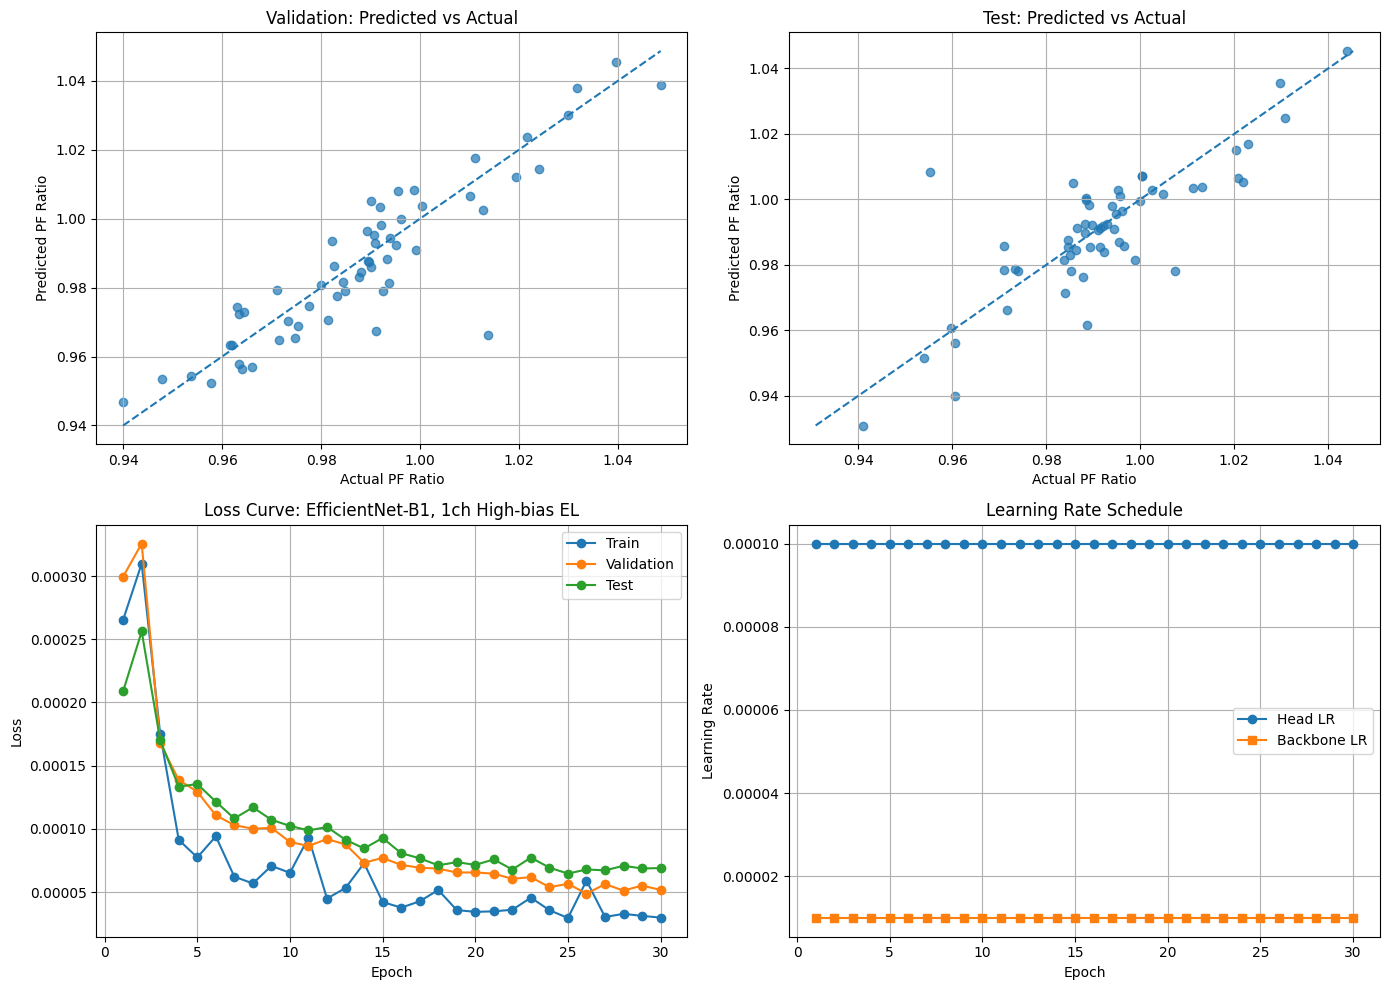


Saved:
- results_b1_unfrozen_1ch_high.png
- val_preds_b1_1ch_high.csv
- test_preds_b1_1ch_high.csv
- b1_unfrozen_1ch_high_best.pth


In [3]:
import os, math, copy, random, time
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"

# EfficientNet-B1 recommended input size
IMAGE_SIZE = 240

# B1 is lighter than B4, so batch 16 should usually fit on RTX 3050 4GB
# If CUDA out of memory, change this to 8 or 4
BATCH_SIZE = 16

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


def set_seed(s=42):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)


set_seed(RANDOM_SEED)


# =========================================================
# PATH + DATAFRAME
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()

    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    for col in ["ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df = df[df["high_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)

    before = len(df)
    df = df[df["high_exists"]].copy()

    print(f"Rows before file filter: {before} | After: {len(df)} | Removed: {before - len(df)}")

    keep = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep += ["high_path", "pf_ratio"]

    return df[keep].reset_index(drop=True)


# =========================================================
# IMAGE LOADING
# =========================================================
def resize_with_padding_gray(img, target_size=240):
    """
    Resize grayscale image while preserving aspect ratio,
    then pad to square target_size x target_size.

    This avoids stretching EL module images.
    """
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


def load_gray_image(path, image_size):
    """
    Safely load grayscale image and resize with padding.
    If loading fails, returns black image instead of crashing.
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return np.zeros((image_size, image_size), dtype=np.uint8)

    img = resize_with_padding_gray(img, image_size)

    return img


# =========================================================
# DATASET
# =========================================================
class SingleELDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        mb = n * self.image_size * self.image_size / (1024 ** 2)

        print(f"\nPreloading {n} high-bias images into RAM (~{mb:.0f} MB)...")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8
        )

        failed = 0

        for i in range(n):
            path = self.df.iloc[i]["high_path"]
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                self.cache_high[i] = 0
                failed += 1
            else:
                self.cache_high[i] = resize_with_padding_gray(img, self.image_size)

        print(
            f"Done in {time.time() - t0:.1f}s | "
            f"RAM: {self.cache_high.nbytes / (1024 ** 2):.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            img = self.cache_high[idx].copy()
        else:
            img = load_gray_image(row["high_path"], self.image_size)

        if self.augment:
            if random.random() < 0.5:
                img = cv2.flip(img, 1)

            if random.random() < 0.5:
                img = cv2.flip(img, 0)

        x = np.expand_dims(img.astype(np.float32) / 255.0, axis=0)

        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, f, lo=0.80, hi=1.20):
        super().__init__()
        self.linear = nn.Linear(f, 1)
        self.lo = lo
        self.hi = hi

    def forward(self, x):
        return torch.sigmoid(self.linear(x)) * (self.hi - self.lo) + self.lo


def build_model(pretrained=True):
    """
    EfficientNet-B1 for 1-channel high-bias EL image input.
    RGB first conv is converted to grayscale by averaging pretrained weights.
    """
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old = model.features[0][0]

    new = nn.Conv2d(
        in_channels=1,
        out_channels=old.out_channels,
        kernel_size=old.kernel_size,
        stride=old.stride,
        padding=old.padding,
        bias=False
    )

    with torch.no_grad():
        if pretrained:
            new.weight[:, 0] = old.weight.mean(dim=1)
        else:
            nn.init.kaiming_normal_(
                new.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

    model.features[0][0] = new

    model.classifier[1] = BoundedOutput(
        model.classifier[1].in_features,
        lo=0.80,
        hi=1.20
    )

    return model


# =========================================================
# TRAINING + EVALUATION
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).unsqueeze(1)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)

    return loss_sum / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    loss_sum = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).unsqueeze(1)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item() * x.size(0)

            preds.extend(out.squeeze(1).cpu().numpy())
            trues.extend(y.squeeze(1).cpu().numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_sum / len(loader.dataset), mae, rmse, r2, preds, trues


def plot_scatter(ax, t, p, title):
    ax.scatter(t, p, alpha=0.7)

    mn = min(t.min(), p.min())
    mx = max(t.max(), p.max())

    ax.plot([mn, mx], [mn, mx], "--")

    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    train_df, temp_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=RANDOM_SEED
    )

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    train_ds = SingleELDataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM
    )

    val_ds = SingleELDataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    test_ds = SingleELDataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    pin_memory = True if DEVICE.type == "cuda" else False

    train_ld = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    val_ld = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    test_ld = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    model = build_model(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    bb = list(model.features.parameters())
    hd = list(model.classifier.parameters())

    print(f"\nBackbone params: {sum(p.numel() for p in bb):,}")
    print(f"Head params:     {sum(p.numel() for p in hd):,}")
    print(f"Total params:    {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": bb, "lr": BACKBONE_LR},
            {"params": hd, "lr": LEARNING_RATE}
        ],
        weight_decay=1e-2
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_wts = copy.deepcopy(model.state_dict())
    best_rmse = float("inf")

    tr_l = []
    vl_l = []
    te_l = []
    h_lr = []
    b_lr = []

    print(
        f"\n{'=' * 70}\n"
        f"EfficientNet-B1 UNFROZEN | High-bias EL | 1 channel | {IMAGE_SIZE}x{IMAGE_SIZE}\n"
        f"{'=' * 70}\n"
    )

    t0 = time.time()

    for ep in range(NUM_EPOCHS):
        et = time.time()

        b_lr.append(optimizer.param_groups[0]["lr"])
        h_lr.append(optimizer.param_groups[1]["lr"])

        train_one_epoch(model, train_ld, criterion, optimizer, DEVICE)

        tl, tm, tr, t2, _, _ = evaluate(model, train_ld, criterion, DEVICE)
        vl, vm, vr, v2, _, _ = evaluate(model, val_ld, criterion, DEVICE)
        xl, xm, xr, x2, _, _ = evaluate(model, test_ld, criterion, DEVICE)

        scheduler.step(vl)

        tr_l.append(tl)
        vl_l.append(vl)
        te_l.append(xl)

        print(
            f"Ep [{ep + 1:02d}/{NUM_EPOCHS}] "
            f"{time.time() - et:.1f}s | "
            f"BB_LR:{b_lr[-1]:.2e} "
            f"Head_LR:{h_lr[-1]:.2e} | "
            f"TrL:{tl:.6f} "
            f"VL:{vl:.6f} "
            f"TL:{xl:.6f} | "
            f"VMAE:{vm:.6f} "
            f"VRMSE:{vr:.6f} "
            f"VR2:{v2:.4f}"
        )

        if vr < best_rmse:
            best_rmse = vr
            best_wts = copy.deepcopy(model.state_dict())

    print(f"\nDone in {time.time() - t0:.1f}s")

    model.load_state_dict(best_wts)

    vl, vm, vr, v2, vp, vt = evaluate(model, val_ld, criterion, DEVICE)
    xl, xm, xr, x2, xp, xt = evaluate(model, test_ld, criterion, DEVICE)

    print(f"\nBest Val  MAE:{vm:.6f} RMSE:{vr:.6f} R2:{v2:.6f}")
    print(f"Test      MAE:{xm:.6f} RMSE:{xr:.6f} R2:{x2:.6f}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_scatter(
        axes[0, 0],
        vt,
        vp,
        "Validation: Predicted vs Actual"
    )

    plot_scatter(
        axes[0, 1],
        xt,
        xp,
        "Test: Predicted vs Actual"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        tr_l,
        "o-",
        label="Train"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        vl_l,
        "o-",
        label="Validation"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        te_l,
        "o-",
        label="Test"
    )

    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].set_title("Loss Curve: EfficientNet-B1, 1ch High-bias EL")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(
        range(1, NUM_EPOCHS + 1),
        h_lr,
        "o-",
        label="Head LR"
    )

    axes[1, 1].plot(
        range(1, NUM_EPOCHS + 1),
        b_lr,
        "s-",
        label="Backbone LR"
    )

    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("Learning Rate Schedule")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()

    plt.savefig(
        "results_b1_unfrozen_1ch_high.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    pd.DataFrame(
        {
            "actual": vt,
            "predicted": vp
        }
    ).to_csv(
        "val_preds_b1_1ch_high.csv",
        index=False
    )

    pd.DataFrame(
        {
            "actual": xt,
            "predicted": xp
        }
    ).to_csv(
        "test_preds_b1_1ch_high.csv",
        index=False
    )

    torch.save(
        model.state_dict(),
        "b1_unfrozen_1ch_high_best.pth"
    )

    print(
        "\nSaved:"
        "\n- results_b1_unfrozen_1ch_high.png"
        "\n- val_preds_b1_1ch_high.csv"
        "\n- test_preds_b1_1ch_high.csv"
        "\n- b1_unfrozen_1ch_high_best.pth"
    )


if __name__ == "__main__":
    main()

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 590
Rows with high-bias EL image existing: 584
Rows removed due to missing high-bias image: 6

Sample rows:
   Make make_plot  split                                          high_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

   pf_ratio  
0  0.952963  
1  0.948889  
2  0.941111  
3  0.954074  
4  0.944074  

Split counts after file filtering:
split
train    463
val       61
test      60
Name: count, dtype: int64

Make by split after file filtering:


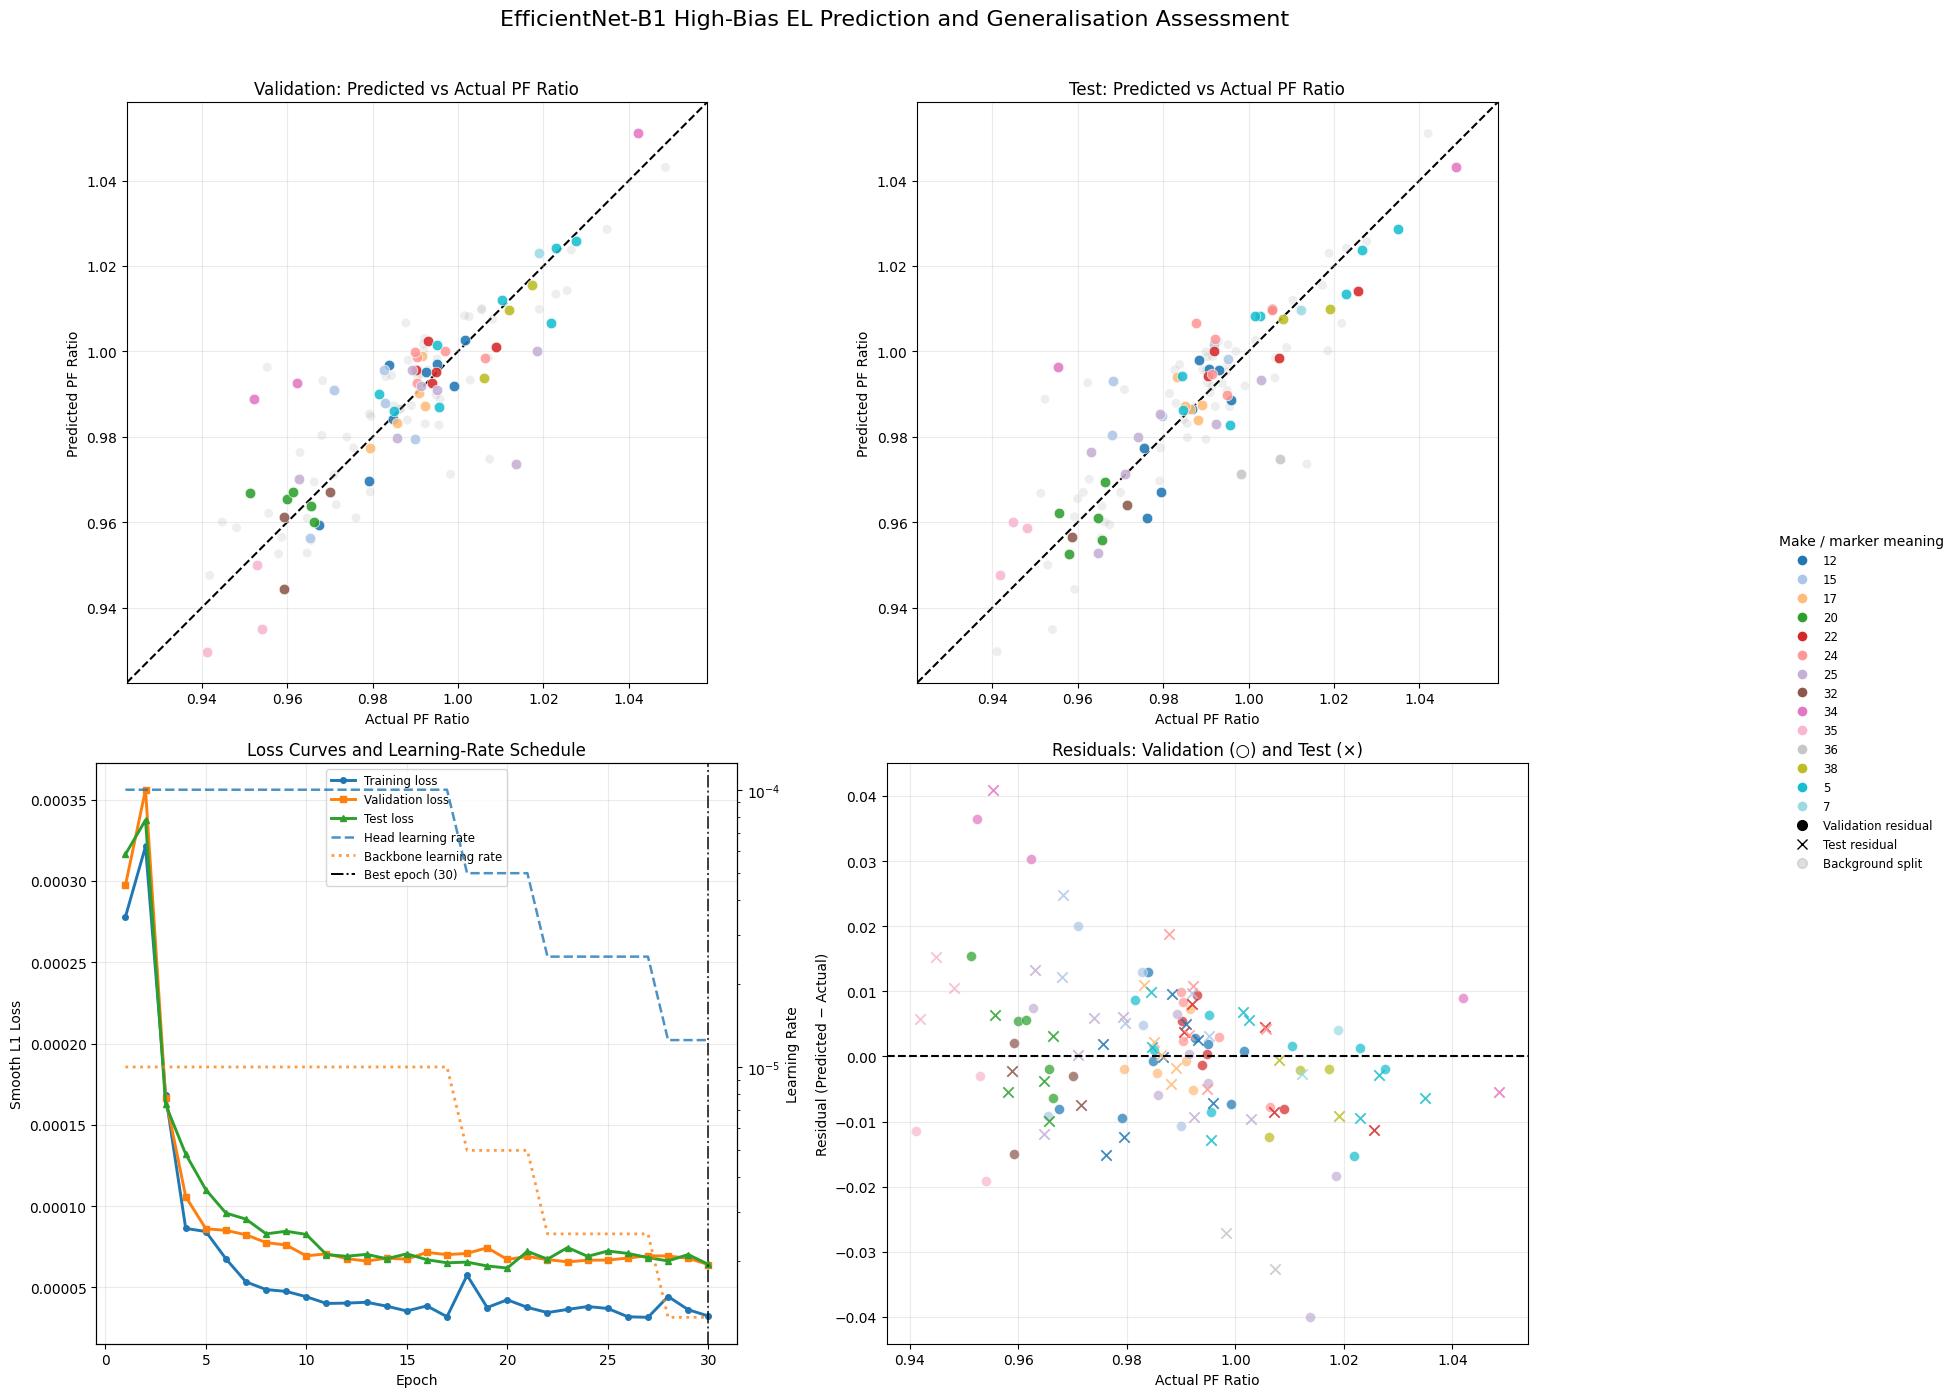


Saved:
- results_effnet_b1_high_fixedsplit_generalization.png
- validation_predictions_effnet_b1_high_fixedsplit.csv
- test_predictions_effnet_b1_high_fixedsplit.csv
- metrics_per_make_effnet_b1_high_fixedsplit.csv
- training_history_effnet_b1_high_fixedsplit.csv
- effnet_b1_high_fixedsplit_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

IMAGE_SIZE = 240
BATCH_SIZE = 16  # reduce to 8 if CUDA runs out of memory
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve paths from the CSV relative to the CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load the fixed-split CSV, compute PF ratio, resolve the high-bias EL path,
    and retain Make and split information for plotting.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )
    df = df[df["high_path"].notna()].copy()

    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with high-bias EL image existing: {total_after}")
    print(f"Rows removed due to missing high-bias image: {total_before - total_after}")

    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()

    valid_split_names = {"train", "val", "test"}
    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c
        for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "high_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_grayscale_tiff(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load image: {path}")

    return img


def resize_with_padding_gray(img, target_size=240):
    """Preserve image aspect ratio and pad to a square input."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


# =========================================================
# DATASET
# =========================================================
class HighBiasELDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        expected_mb = n * self.image_size * self.image_size / (1024 ** 2)

        print(f"\nPreloading {n} high-bias images into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()
        self.cache_high = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )

        failed = 0
        for i in range(n):
            row = self.df.iloc[i]
            try:
                high_img = read_grayscale_tiff(row["high_path"])
                self.cache_high[i] = resize_with_padding_gray(
                    high_img, self.image_size
                )
            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = self.cache_high.nbytes / (1024 ** 2)
        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )
        self.cache = True

    def apply_augmentation(self, img):
        if random.random() < 0.5:
            img = cv2.flip(img, 1)
        if random.random() < 0.5:
            img = cv2.flip(img, 0)
        return img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
        else:
            high_img = read_grayscale_tiff(row["high_path"])
            high_img = resize_with_padding_gray(high_img, self.image_size)

        if self.augment:
            high_img = self.apply_augmentation(high_img)

        high_img = high_img.astype(np.float32) / 255.0
        x = np.expand_dims(high_img, axis=0)  # [1, H, W]
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_1ch(pretrained=True):
    """EfficientNet-B1 modified for one high-bias grayscale EL channel."""
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        if pretrained:
            new_conv.weight[:, 0, :, :] = old_conv.weight.mean(dim=1)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features, min_val=0.80, max_val=1.20
    )
    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    """Create a stable qualitative colour palette for all Make values."""
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    # tab20 is clear and publication-friendly for up to roughly 20 categories.
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    """Highlight one split by Make and show the other split in faint grey."""
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    """
    Left axis: training, validation, and test loss.
    Right axis: head and backbone learning rates.
    """
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    # Include the best-epoch line in the combined legend.
    best_epoch_handle = Line2D(
        [0], [0], linestyle="-.", color="black", linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="best",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    """
    Residual plot helps reveal systematic bias, heteroscedasticity,
    and differences between validation and test behaviour.
    """
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted − Actual)")
    ax.set_title("Residuals: Validation (○) and Test (×)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after file filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after file filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError("Train, validation, or test split is empty after filtering.")

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = HighBiasELDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = HighBiasELDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = HighBiasELDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_1ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B1, high-bias EL, fixed split CSV")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING THE BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss − training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss − training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df, val_trues, val_preds, "validation"
    )
    test_results_df = make_prediction_table(
        test_df, test_trues, test_preds, "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: Predicted vs Actual PF Ratio",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: Predicted vs Actual PF Ratio",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1], val_results_df, test_results_df, make_palette
    )

    # One shared legend for Make categories.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="None", color="black",
            markersize=7, label="Validation residual"
        ),
        Line2D(
            [0], [0], marker="x", linestyle="None", color="black",
            markersize=7, label="Test residual"
        ),
        Line2D(
            [0], [0], marker="o", linestyle="None", color="grey",
            alpha=0.25, markersize=7, label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B1 High-Bias EL Prediction and Generalisation Assessment",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_effnet_b1_high_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b1_high_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b1_high_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b1_high_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b1_high_fixedsplit.csv"
    model_path = "effnet_b1_high_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df, "validation"
    )
    test_make_metrics = calculate_metrics_per_make(
        test_results_df, "test"
    )
    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics], ignore_index=True
    )
    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )
    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
   Make make_plot  split                                           low_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Insti

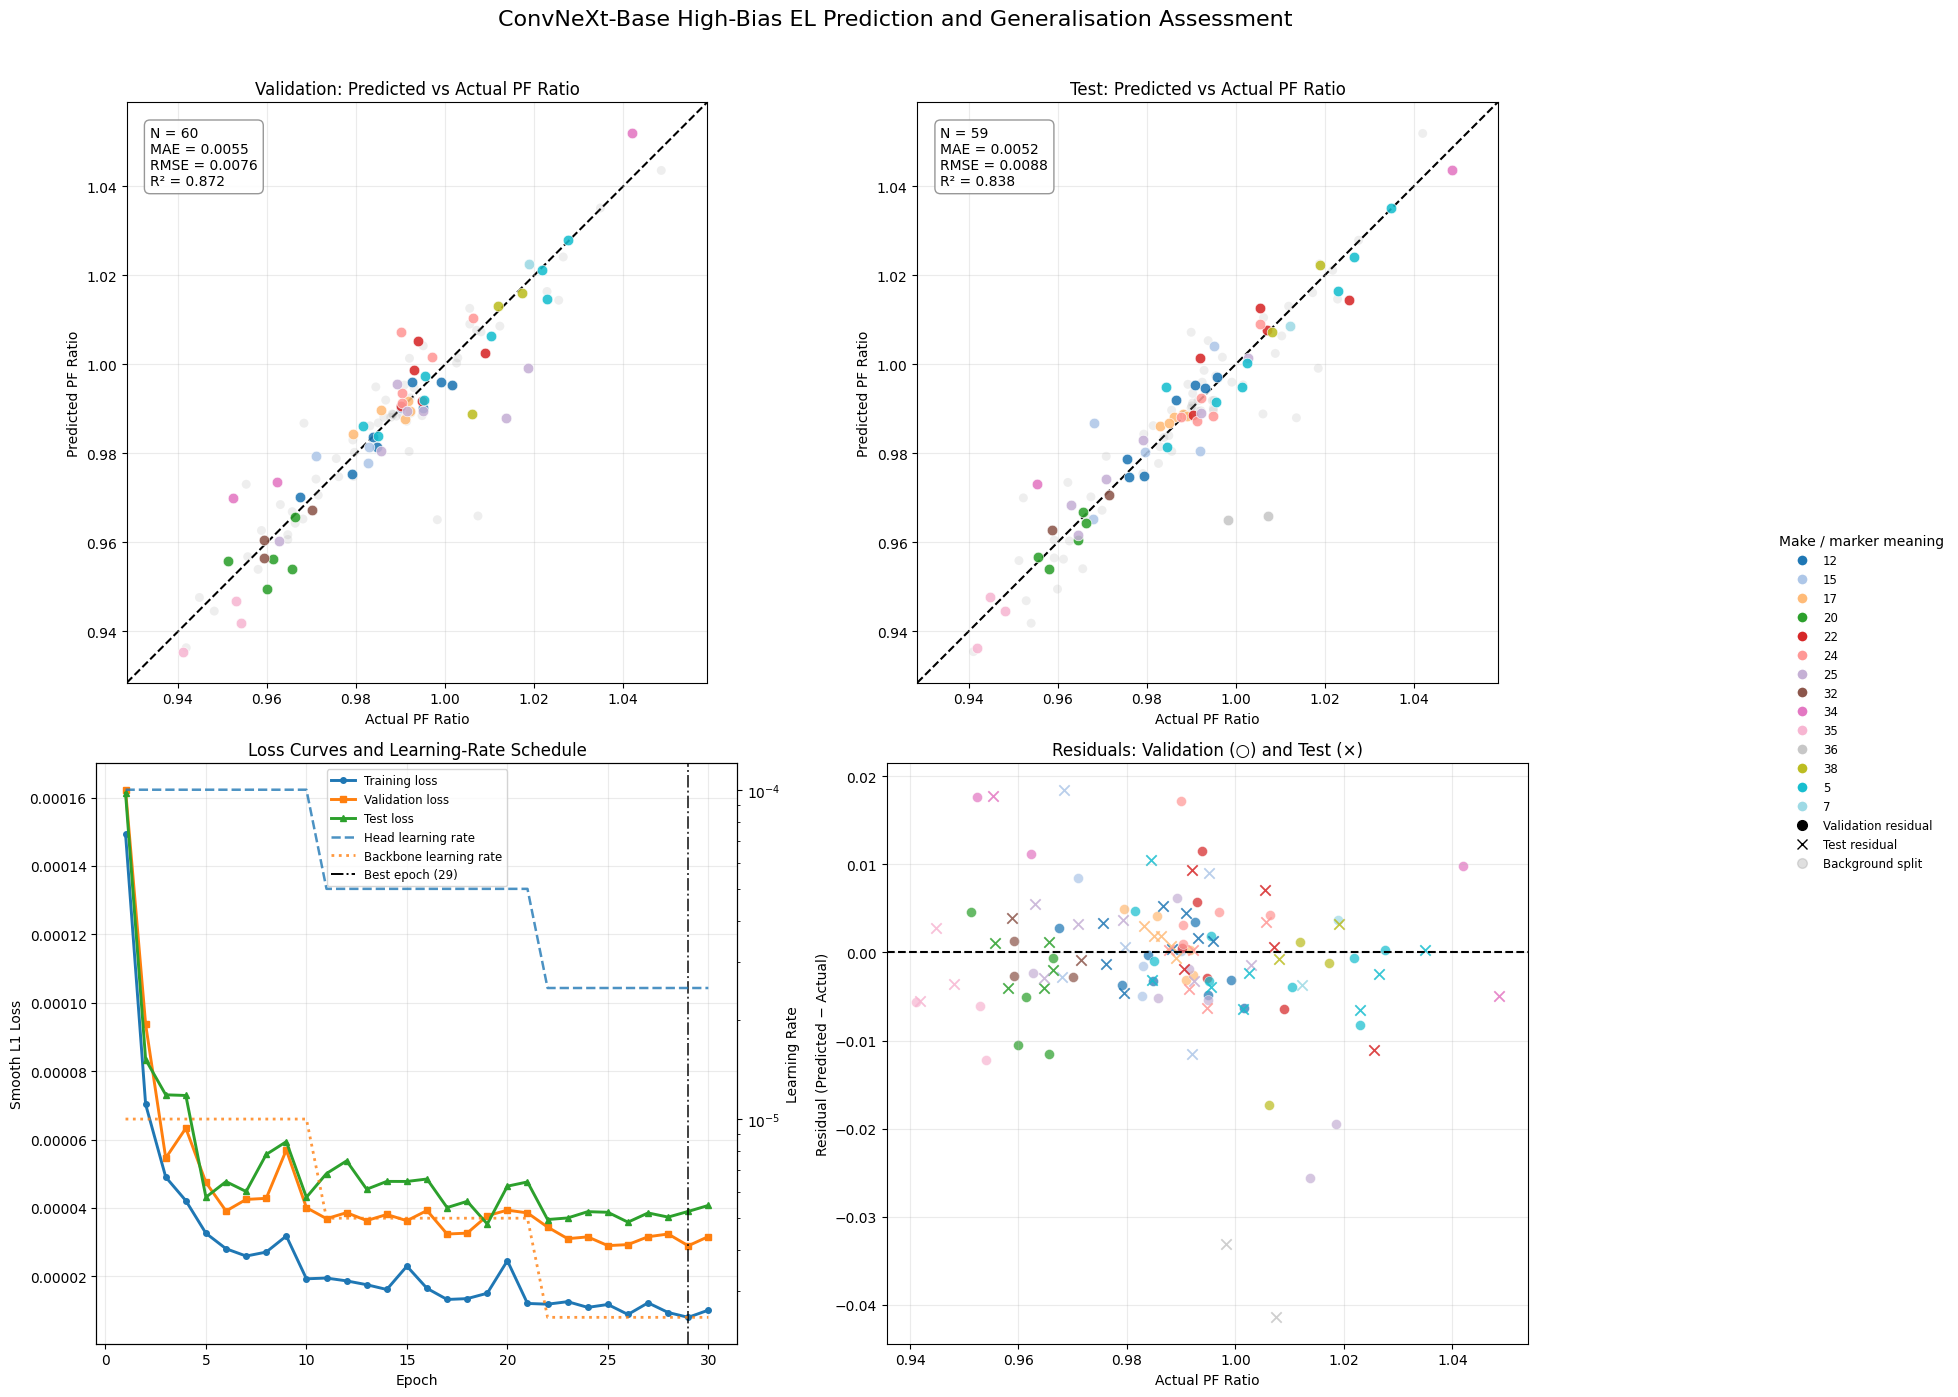


Saved:
- results_convnext_base_highbias_fixedsplit_generalization_metrics.png
- validation_predictions_convnext_base_highbias_fixedsplit.csv
- test_predictions_convnext_base_highbias_fixedsplit.csv
- metrics_per_make_convnext_base_highbias_fixedsplit.csv
- training_history_convnext_base_highbias_fixedsplit.csv
- convnext_base_highbias_fixedsplit_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

IMAGE_SIZE = 224
BATCH_SIZE = 2  # ConvNeXt-Base is heavy on a 4 GB RTX 3050; use 1 if CUDA runs out of memory
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve paths from the CSV relative to the CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load the fixed-split CSV, compute PF ratio, resolve image paths,
    and retain Make and split information for plotting.

    Both low- and high-bias files are checked so that this high-bias-only
    experiment uses the same eligible sample set as the dual-bias experiment.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELLPath",
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["low_path"] = df["ELLPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )
    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )

    df = df[df["low_path"].notna() & df["high_path"].notna()].copy()

    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    df[SPLIT_COLUMN] = (
        df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    )

    valid_split_names = {"train", "val", "test"}
    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c
        for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "low_path",
        "high_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_grayscale_tiff(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load image: {path}")

    return img


def resize_with_padding_gray(img, target_size=224):
    """Preserve image aspect ratio and pad to a square input."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


# =========================================================
# DATASET: HIGH-BIAS EL ONLY
# =========================================================
class HighBiasELDataset(Dataset):
    """Dataset using only the high-bias EL image as a single input channel."""

    def __init__(self, dataframe, image_size=224, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        expected_mb = n * self.image_size * self.image_size / (1024 ** 2)

        print(f"\nPreloading {n} high-bias images into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                high_img = read_grayscale_tiff(row["high_path"])
                self.cache_high[i] = resize_with_padding_gray(
                    high_img, self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = self.cache_high.nbytes / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_augmentation(self, high_img):
        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            high_img = cv2.flip(high_img, 0)

        return high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            high_img = self.cache_high[idx].copy()
        else:
            high_img = read_grayscale_tiff(row["high_path"])
            high_img = resize_with_padding_gray(high_img, self.image_size)

        if self.augment:
            high_img = self.apply_augmentation(high_img)

        high_img = high_img.astype(np.float32) / 255.0

        # [H, W] -> [1, H, W]
        x = np.expand_dims(high_img, axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_1ch(pretrained=True):
    """ConvNeXt-Base modified for one-channel high-bias grayscale EL input."""
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem convolution: features[0][0].
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=(old_conv.bias is not None),
        padding_mode=old_conv.padding_mode,
    )

    with torch.no_grad():
        if pretrained:
            # Initialise the grayscale channel using the mean RGB filter.
            new_conv.weight[:, 0, :, :] = old_conv.weight.mean(dim=1)

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )
            if new_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier: LayerNorm -> Flatten -> Linear.
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features, min_val=0.80, max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    """Create a stable qualitative colour palette for all Make values."""
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    # tab20 is clear and publication-friendly for up to roughly 20 categories.
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
    mae,
    rmse,
    r2,
):
    """Highlight one split by Make and show the other split in faint grey."""
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    # Display overall regression metrics for the highlighted split.
    metrics_text = (
        f"N = {len(focus_df)}\n"
        f"MAE = {mae:.4f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"R² = {r2:.3f}"
    )
    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": "0.55",
            "alpha": 0.90,
        },
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    """
    Left axis: training, validation, and test loss.
    Right axis: head and backbone learning rates.
    """
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    # Include the best-epoch line in the combined legend.
    best_epoch_handle = Line2D(
        [0], [0], linestyle="-.", color="black", linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="best",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    """
    Residual plot helps reveal systematic bias, heteroscedasticity,
    and differences between validation and test behaviour.
    """
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted − Actual)")
    ax.set_title("Residuals: Validation (○) and Test (×)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after file filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after file filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError("Train, validation, or test split is empty after filtering.")

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = HighBiasELDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = HighBiasELDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = HighBiasELDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_1ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, high-bias EL, fixed split CSV")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING THE BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss − training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss − training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df, val_trues, val_preds, "validation"
    )
    test_results_df = make_prediction_table(
        test_df, test_trues, test_preds, "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: Predicted vs Actual PF Ratio",
        background_label="Test background",
        axis_limits=axis_limits,
        mae=val_mae,
        rmse=val_rmse,
        r2=val_r2,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: Predicted vs Actual PF Ratio",
        background_label="Validation background",
        axis_limits=axis_limits,
        mae=test_mae,
        rmse=test_rmse,
        r2=test_r2,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1], val_results_df, test_results_df, make_palette
    )

    # One shared legend for Make categories.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="None", color="black",
            markersize=7, label="Validation residual"
        ),
        Line2D(
            [0], [0], marker="x", linestyle="None", color="black",
            markersize=7, label="Test residual"
        ),
        Line2D(
            [0], [0], marker="o", linestyle="None", color="grey",
            alpha=0.25, markersize=7, label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base High-Bias EL Prediction and Generalisation Assessment",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_convnext_base_highbias_fixedsplit_generalization_metrics.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_highbias_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_highbias_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_highbias_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_highbias_fixedsplit.csv"
    model_path = "convnext_base_highbias_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df, "validation"
    )
    test_make_metrics = calculate_metrics_per_make(
        test_results_df, "test"
    )
    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics], ignore_index=True
    )
    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )
    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")
